In [1]:
import numpy as np

import sklearn
from sklearn.model_selection import train_test_split
from sklearn import linear_model

import matplotlib
import matplotlib.pyplot as plt


In [2]:
# Independent data
nsamp = 100
xdat = np.random.uniform(-2,7,nsamp)

# Data:
beta = np.array([4.342, -0.7, 2.7])
y0 = beta[0] + beta[1] * np.exp(-xdat/2) + beta[2] * np.exp(-xdat)
wstd = 0.2 # noise
ydat = y0 + np.random.normal(0,wstd,nsamp)

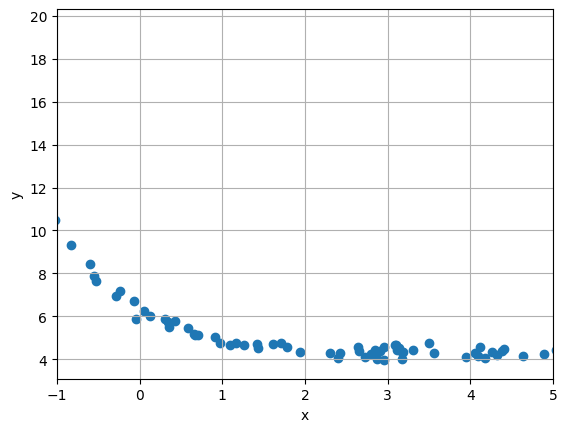

In [3]:
plt.scatter(xdat,ydat)
plt.xlim([-1,5])
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

In [4]:
# Split
utr, uts, ytr, yts = train_test_split(xdat, ydat, test_size=0.5)

In [5]:
utr.shape

(50,)

In [6]:
ytr.shape

(50,)

In [7]:
d = 3
print_tr = np.exp(utr[:, None] * np.arange(1, d+1)/(-d))
print(print_tr)

[[1.80667618e-01 3.26407883e-02 5.89713349e-03]
 [1.60435249e-01 2.57394692e-02 4.12951817e-03]
 [1.76474183e-01 3.11431372e-02 5.49595969e-03]
 [3.11645155e-01 9.71227028e-02 3.02678198e-02]
 [2.29804522e-01 5.28101181e-02 1.21360039e-02]
 [1.58550318e+00 2.51382033e+00 3.98567013e+00]
 [1.43884769e+00 2.07028267e+00 2.97882144e+00]
 [1.02401251e+00 1.04860162e+00 1.07378117e+00]
 [1.04309528e-01 1.08804776e-02 1.13493748e-03]
 [6.78214969e-01 4.59975544e-01 3.11962299e-01]
 [3.32492735e-01 1.10551419e-01 3.67575436e-02]
 [1.77976690e-01 3.16757023e-02 5.63753665e-03]
 [1.51371688e-01 2.29133879e-02 3.46843820e-03]
 [2.48027810e-01 6.15177945e-02 1.52581238e-02]
 [1.50507773e-01 2.26525898e-02 3.40939085e-03]
 [7.37200889e-01 5.43465150e-01 4.00642992e-01]
 [8.03032827e-01 6.44861721e-01 5.17845131e-01]
 [6.57418439e-01 4.32199005e-01 2.84135595e-01]
 [1.86420307e-01 3.47525309e-02 6.47857748e-03]
 [2.13472618e-01 4.55705585e-02 9.72806640e-03]
 [1.74893234e-01 3.05876433e-02 5.349571

## using sklearn:

In [ ]:
# Fit:
MSE = []
dtest = np.arange(1,12)

for d in dtest:
    # model using train data:
    Xtr = np.exp(utr[:, None] * np.arange(1, d+1)/(-d))
    model = linear_model.LinearRegression()
    model.fit(Xtr, ytr)

    # predict with test data:
    Xts = np.exp(uts[:, None] * np.arange(1, d+1)/(-d))
    yhat = model.predict(Xts)

    # find mse:
    MSE.append(np.mean((yhat - yts)**2))

    print("intercept for d = {0:2d} is {1:f}".format(d, model.intercept_), " coefficients: ", *model.coef_)

print(MSE)

## using linalg:

In [ ]:
MSE_np = []
for d_np in dtest:
    # model:
    Xtr = np.exp(utr[:, None] * np.arange(d_np+1)/(-d_np))
    out = np.linalg.lstsq(Xtr, ytr, rcond=None)

    # predict:
    Xts = np.exp(uts[:, None] * np.arange(d_np+1)/(-d_np))
    yhat = Xts @ out[0]

    MSE_np.append(np.mean((yhat - yts)**2))

    print("intercept for d = {0:2d} is {1:f}".format(d_np, out[0][0]), " coefficients: ", *out[0][1:] )

print(MSE_np)


## Compare:

In [ ]:
np.sum((np.array(MSE) - np.array(MSE_np))**2)

In [ ]:
plt.plot(dtest, MSE, 'o-')
plt.xlabel('Model order')
plt.ylabel('MSE on test data')
plt.grid()

In [ ]:
print(MSE.index(min(MSE)) + 1)

## Matrix multiplication check:

In [ ]:
A = np.arange(-5,6,2).reshape(2,3)
b = np.array([[2],[-9],[7]]).reshape(3,)
print(A)
print(b)

In [ ]:
A@b